In [81]:
print('ciao mondo')

ciao mondo


In [96]:
import pandas as pd  #mi importo la liberia pandas
from sklearn.tree import DecisionTreeRegressor #mi importo una parte della libreria DecisionTreeRegressor 
from sklearn.model_selection import train_test_split #che divide un dataset in due parti: una per l'addestramento del modello (training set) e una per la valutazione del modello (test set)*.
from sklearn.metrics import accuracy_score #che calcola l'accuratezza di un modello

df = pd.read_csv('vgsales.csv') #read_csv mi fa leggere il file csv
df.shape #mi stampa quandi righe e colonne e formanìto


(16598, 11)

In [83]:
df.dtypes

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [84]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [85]:
df.values #mi stampa solo i valori 

array([[1, 'Wii Sports', 'Wii', ..., 3.77, 8.46, 82.74],
       [2, 'Super Mario Bros.', 'NES', ..., 6.81, 0.77, 40.24],
       [3, 'Mario Kart Wii', 'Wii', ..., 3.79, 3.31, 35.82],
       ...,
       [16598, 'SCORE International Baja 1000: The Official Game', 'PS2',
        ..., 0.0, 0.0, 0.01],
       [16599, 'Know How 2', 'DS', ..., 0.0, 0.0, 0.01],
       [16600, 'Spirits & Spells', 'GBA', ..., 0.0, 0.0, 0.01]],
      shape=(16598, 11), dtype=object)

In [86]:
X = df.drop(columns=['Name','Genre','Platform','Publisher',], axis=1) #mi cancella una colonna 
X

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,2006.0,41.49,29.02,3.77,8.46,82.74
1,2,1985.0,29.08,3.58,6.81,0.77,40.24
2,3,2008.0,15.85,12.88,3.79,3.31,35.82
3,4,2009.0,15.75,11.01,3.28,2.96,33.00
4,5,1996.0,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...
16593,16596,2002.0,0.01,0.00,0.00,0.00,0.01
16594,16597,2003.0,0.01,0.00,0.00,0.00,0.01
16595,16598,2008.0,0.00,0.00,0.00,0.00,0.01
16596,16599,2010.0,0.00,0.01,0.00,0.00,0.01


In [87]:
X.head()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,2006.0,41.49,29.02,3.77,8.46,82.74
1,2,1985.0,29.08,3.58,6.81,0.77,40.24
2,3,2008.0,15.85,12.88,3.79,3.31,35.82
3,4,2009.0,15.75,11.01,3.28,2.96,33.00
4,5,1996.0,11.27,8.89,10.22,1.00,31.37


In [88]:
y = df['JP_Sales']
y

0         3.77
1         6.81
2         3.79
3         3.28
4        10.22
         ...  
16593     0.00
16594     0.00
16595     0.00
16596     0.00
16597     0.00
Name: JP_Sales, Length: 16598, dtype: float64

In [89]:
#divide il dataset x e y in due parti: una per l'addestramento del 
#modello (x_train e y_train) e una per la valutazione del modello 
#(x_test e y_test), con il 20% dei dati assegnati al test set
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [90]:
X_train

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
4282,4284,2006.0,0.09,0.24,0.00,0.12,0.46
11365,11367,2009.0,0.04,0.03,0.00,0.01,0.08
10056,10058,2009.0,0.11,0.00,0.00,0.01,0.11
15930,15933,2015.0,0.00,0.00,0.02,0.00,0.02
10061,10063,2010.0,0.10,0.00,0.00,0.01,0.11
...,...,...,...,...,...,...,...
13075,13077,2015.0,0.00,0.00,0.05,0.00,0.05
9242,9244,2011.0,0.00,0.00,0.14,0.00,0.14
13522,13524,2008.0,0.00,0.00,0.04,0.00,0.04
10440,10442,2003.0,0.05,0.04,0.00,0.01,0.10


In [91]:
model = DecisionTreeRegressor() # crea un modello di regressione ad albero di decisione
model.fit(X_train, y_train) #addestra il modello sui dati x e y per imparare a prevedere la variabile target.

predictions = model.predict(X_test) #utilizza il modello addestrato per fare previsioni sui nuovi dati
predictions

array([0.05, 0.06, 0.  , ..., 0.03, 0.  , 0.12], shape=(3320,))

In [92]:
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

logistc regression

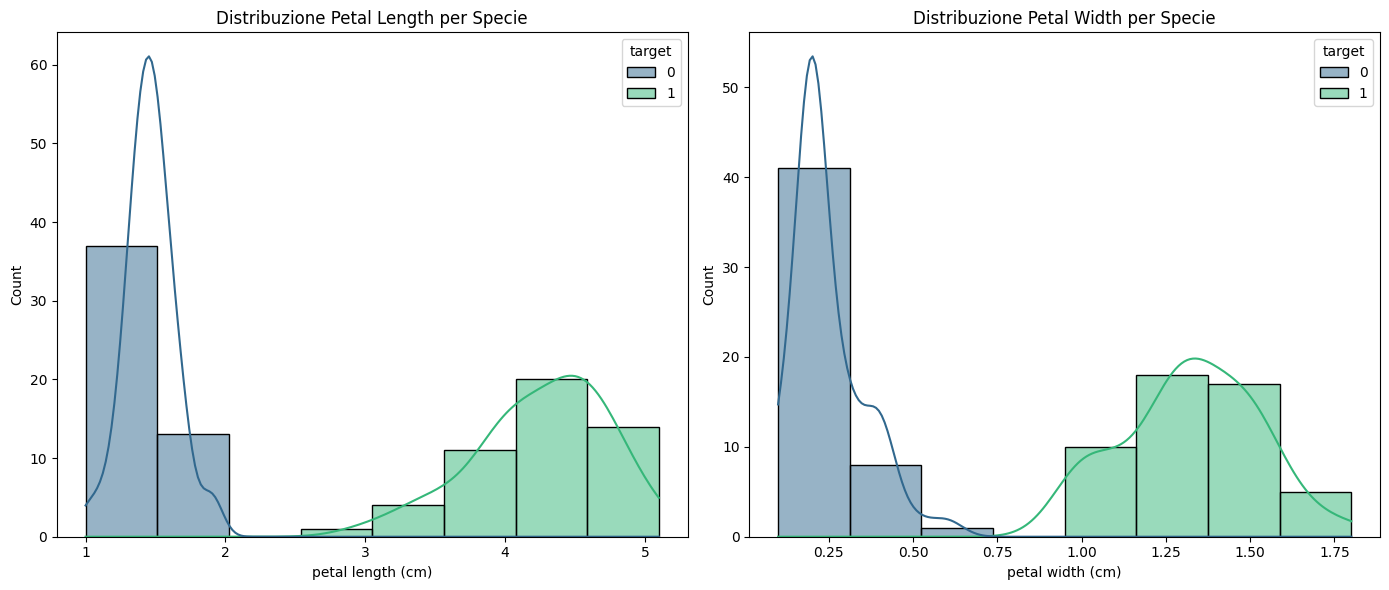

In [8]:
# Distribuzione delle singole features per classe
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(data=data_binary, x='petal length (cm)', hue='target', kde=True, ax=axes[0], palette='viridis')
axes[0].set_title('Distribuzione Petal Length per Specie')
sns.histplot(data=data_binary, x='petal width (cm)', hue='target', kde=True, ax=axes[1], palette='viridis')
axes[1].set_title('Distribuzione Petal Width per Specie')
plt.tight_layout()
plt.show()

In [9]:
# Divisione del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [10]:
print(f"\nDimensione del set di training: {X_train.shape[0]} samples")
print(f"Dimensione del set di test: {X_test.shape[0]} samples")
print(f"Distribuzione delle classi nel training set:\n{y_train.value_counts()}")
print(f"Distribuzione delle classi nel test set:\n{y_test.value_counts()}")


Dimensione del set di training: 75 samples
Dimensione del set di test: 25 samples
Distribuzione delle classi nel training set:
target
1    38
0    37
Name: count, dtype: int64
Distribuzione delle classi nel test set:
target
0    13
1    12
Name: count, dtype: int64


In [11]:
# Creazione del modello di regressione logistica
# max_iter è aumentato per garantire la convergenza 
# per alcuni dataset
model = LogisticRegression(solver='liblinear', random_state=42, max_iter=200)


In [12]:
# Addestramento del modello sul set di training
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,200
,multi_class,'deprecated'


In [13]:
# Visualizzazione dei coefficienti e dell'intercetta
print("\nCoefficienti del modello (beta_i):")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"\nIntercetta del modello (beta_0): {model.intercept_[0]:.4f}")


Coefficienti del modello (beta_i):
sepal length (cm): -0.3191
sepal width (cm): -1.4320
petal length (cm): 2.0611
petal width (cm): 0.9362

Intercetta del modello (beta_0): -0.2449


In [14]:
# Effettuare predizioni sul set di test
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probabilità della classe positiva


In [15]:
# Calcolo delle metriche di valutazione
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=[target_names[0], target_names[1]])


In [16]:
print(f"\nAccuratezza del modello: {accuracy:.4f}")
print("\nMatrice di Confusione:\n", conf_matrix)
print("\nReport di Classificazione:\n", class_report)


Accuratezza del modello: 1.0000

Matrice di Confusione:
 [[13  0]
 [ 0 12]]

Report di Classificazione:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      1.00      1.00        12

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



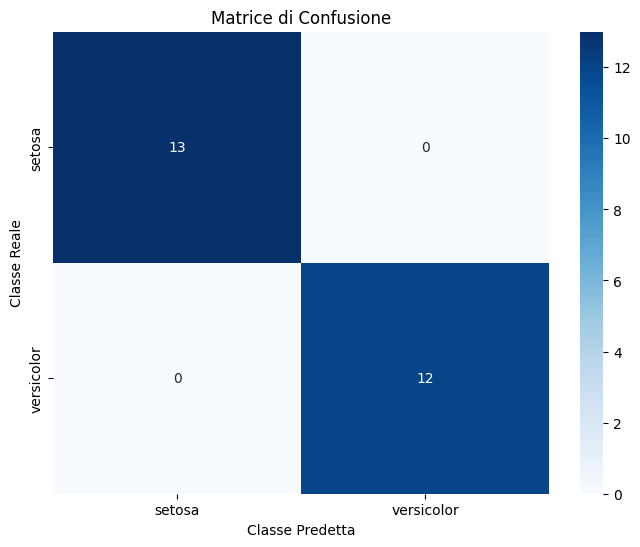

In [17]:
# Visualizzazione della Matrice di Confusione
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[target_names[0], target_names[1]],
            yticklabels=[target_names[0], target_names[1]])
plt.xlabel('Classe Predetta')
plt.ylabel('Classe Reale')
plt.title('Matrice di Confusione')
plt.show()

In [18]:
# Curva ROC (Receiver Operating Characteristic) - 
# utile per problemi di classificazione binaria
from sklearn.metrics import roc_curve, roc_auc_score

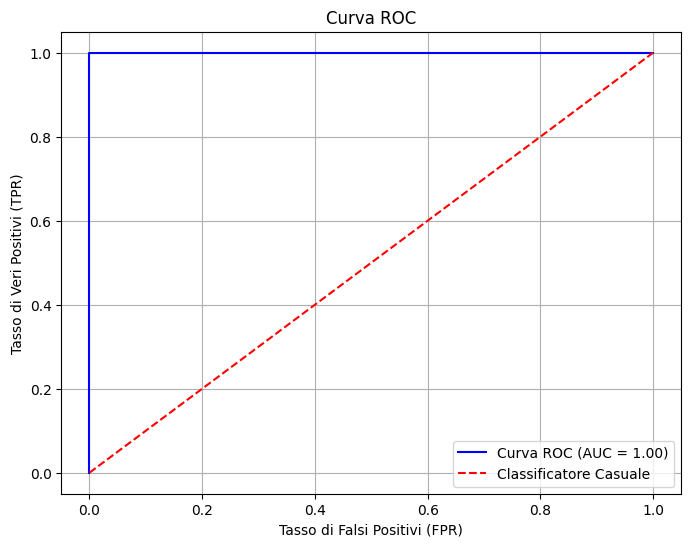

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Classificatore Casuale')
plt.xlabel('Tasso di Falsi Positivi (FPR)')
plt.ylabel('Tasso di Veri Positivi (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

Ingegneria delle carateristiche


In [41]:
#Iniziamo con un dataset di esempio che include il prezzo, le stanze e il quartiere delle case.
import pandas as pd

data = [
    {'price': 850000, 'rooms': 4, 'neighborhood': 'Queen Anne'},
    {'price': 700000, 'rooms': 3, 'neighborhood': 'Fremont'},
    {'price': 650000, 'rooms': 3, 'neighborhood': 'Wallingford'},
    {'price': 600000, 'rooms': 2, 'neighborhood': 'Fremont'}
]

df = pd.DataFrame(data)
print(df)

    price  rooms neighborhood
0  850000      4   Queen Anne
1  700000      3      Fremont
2  650000      3  Wallingford
3  600000      2      Fremont


In [42]:
#Si potrebbe essere tentati di codificare i dati categorici 
#con una semplice mappatura numerica. Il LabelEncoder di 
#Scikit-Learn può convertire le stringhe 
#(o etichette categoriche) in valori numerici.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
x_encoded = le.fit_transform(df["neighborhood"])
print(x_encoded)

[1 0 2 0]


In [43]:
#Una tecnica efficace è l'One-Hot Encoding. 
#Questa tecnica crea colonne aggiuntive che indicano 
#la presenza (1) o l'assenza (0) di una categoria. 
#Quando i dati sono in un elenco di dizionari, DictVectorizer 
#di Scikit-Learn può trasformarli in vettori.
from sklearn.feature_extraction import DictVectorizer

vec = DictVectorizer(sparse=False, dtype=int)
transformed_data = vec.fit_transform(data)
print(transformed_data)

[[     0      1      0 850000      4]
 [     1      0      0 700000      3]
 [     0      0      1 650000      3]
 [     1      0      0 600000      2]]


In [44]:
#Per capire il significato di ciascuna colonna, 
#possiamo controllare i nomi delle caratteristiche:
print(vec.get_feature_names_out())


['neighborhood=Fremont' 'neighborhood=Queen Anne'
 'neighborhood=Wallingford' 'price' 'rooms']


In [45]:
#Un potenziale svantaggio di questo approccio è che se 
#la categoria ha molti valori possibili, la dimensione del 
#dataset può aumentare notevolmente. Tuttavia, poiché 
#i dati codificati contengono principalmente zeri, 
# un output sparso può essere molto efficiente.
vec = DictVectorizer(sparse=True, dtype=int)
X = vec.fit_transform(data)
print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 12 stored elements and shape (4, 5)>
  Coords	Values
  (0, 1)	1
  (0, 3)	850000
  (0, 4)	4
  (1, 0)	1
  (1, 3)	700000
  (1, 4)	3
  (2, 2)	1
  (2, 3)	650000
  (2, 4)	3
  (3, 0)	1
  (3, 3)	600000
  (3, 4)	2


In [46]:
#Possiamo visualizzare 
#questa matrice sparsa correttamente usando Pandas:
import pandas as pd
pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())

,neighborhood=Fremont,neighborhood=Queen Anne,neighborhood=Wallingford,price,rooms
0,0,1,0,850000,4
1,1,0,0,700000,3
2,0,0,1,650000,3
3,1,0,0,600000,2


In [47]:
#Un altro strumento per il One-Hot Encoding 
#è sklearn.preprocessing.OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

x=[["casa","no"],["non casa","si"],["casa","no"],["non casa","si"]]
y =[0,1,0,1]

X = pd.DataFrame(x)
y = pd.Series(y)
print(X, y)

# Preprocessing: encoder per colonna categorica
one_hot = OneHotEncoder(sparse_output=False)
X = one_hot.fit_transform(X)
print(X)


          0   1
0      casa  no
1  non casa  si
2      casa  no
3  non casa  si 0    0
1    1
2    0
3    1
dtype: int64
[[1. 0. 1. 0.]
 [0. 1. 0. 1.]
 [1. 0. 1. 0.]
 [0. 1. 0. 1.]]


come funziona Scikit-Learn per un problema di regressione lineare.

In [48]:
import numpy as np # Per operazioni numeriche (es. generazione di dati)
import matplotlib.pyplot as plt # Per la visualizzazione
from sklearn.linear_model import LinearRegression # Il modello di regressione lineare
from sklearn.model_selection import train_test_split # Per dividere i dati
from sklearn.metrics import mean_squared_error, r2_score # Per valutare il modello


In [52]:
# 1. Caricare i dati (o generarli per questo esempio)
# Generiamo un dataset sintetico per la regressione lineare
np.random.seed(0) # Per riproducibilità
X = np.random.rand(100, 1) * 10 # 100 punti tra 0 e 10
y = 2 * X + 1 + np.random.randn(100, 1) * 2 # y = 2x + 1 + rumore

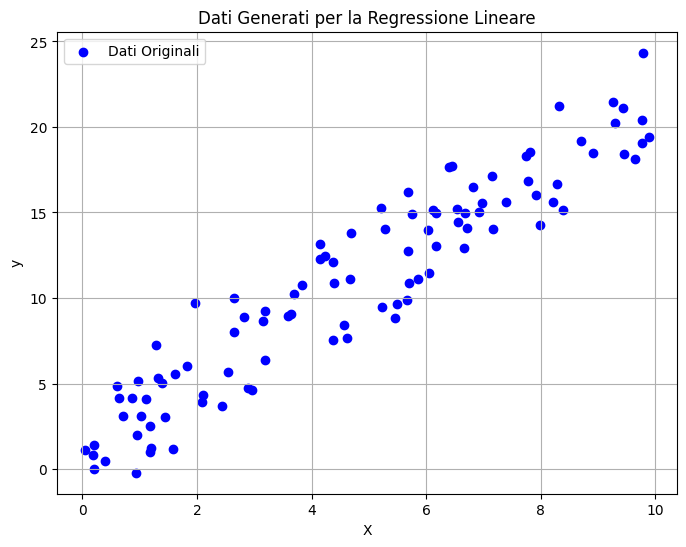

In [53]:
# 2. Ispezionare i dati
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Dati Originali')
plt.title('Dati Generati per la Regressione Lineare')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

In [54]:
# 3. Pre-elaborare i dati (se necessario, in questo caso 
# solo la divisione)
# Dividere i dati in set di training e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensione del set di training: {X_train.shape[0]} campioni")
print(f"Dimensione del set di test: {X_test.shape[0]} campioni")

Dimensione del set di training: 80 campioni
Dimensione del set di test: 20 campioni


In [55]:
# 4. Scegliere e addestrare il modello
# Creare un'istanza del modello di regressione lineare
model = LinearRegression()

# Addestrare il modello utilizzando i dati di training
model.fit(X_train, y_train)

print(f"\nCoefficiente (pendenza): {model.coef_[0][0]:.2f}")
print(f"Intercetta: {model.intercept_[0]:.2f}")


Coefficiente (pendenza): 2.00
Intercetta: 1.41


In [ ]:
# 5. Effettuare predizioni sul set di test
y_pred = model.predict(X_test)
y_pred


Errore Quadratico Medio (MSE): 3.67
Coefficiente di Determinazione (R^2): 0.85


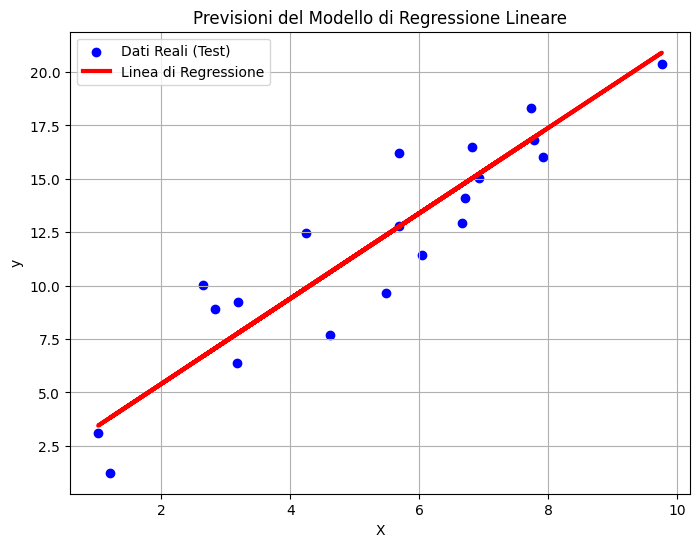

In [58]:
# 6. Valutare il modello
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nErrore Quadratico Medio (MSE): {mse:.2f}")
print(f"Coefficiente di Determinazione (R^2): {r2:.2f}")

# Visualizzare la linea di regressione sul set di test
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', label='Dati Reali (Test)')
plt.plot(X_test, y_pred, color='red', linewidth=3, label='Linea di Regressione')
plt.title('Previsioni del Modello di Regressione Lineare')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()